# Libraries

In [1]:
# Data Preparation
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
# Data Preprocessing
from transformers import AutoTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
import nltk
import string

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Visualization
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

from tqdm import tqdm

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Device

In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


# Data Preprocessing & Preparation

In [3]:
# Initialize 
# Load a pre-trained tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
stop_words_list = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [4]:
from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

# Preprocessing pipelien
transform_pipeline = preprocessing.Compose([
    preprocessing.Lowercase(),
    preprocessing.Tokenize(tokenizer),
    preprocessing.StopwordsRemoval(stop_words_list),
    preprocessing.POStagging(),
    preprocessing.Lemmatization(lemmatizer), 
])

In [5]:
# 1. Load dataset and apply prior Transform 
train_dataset = IMDBDataset(base_path='aclImdb', size=2000, train=True, transform=transform_pipeline)
test_dataset = IMDBDataset(base_path='aclImdb', size=1000, train=False, transform=transform_pipeline)

# 2. Extract preprocessed texts and labels
train_input = [train_dataset[i][0] for i in range(len(train_dataset))]
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

test_input = [test_dataset[i][0] for i in range(len(test_dataset))]
test_labels = [test_dataset[i][1] for i in range(len(test_dataset))]

# 3. Apply TF-IDF to the whole dataset
vectorizer = TfidfVectorizer(max_features=250)
train_embedded_features = vectorizer.fit_transform(train_input).toarray()
test_embedded_features = vectorizer.transform(test_input).toarray() #use same transformer as train set

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
y_train_tensor = torch.tensor(train_labels, dtype=torch.long)

X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

# 5. Construct dataset for dataloader
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

Token indices sequence length is longer than the specified maximum sequence length for this model (1009 > 512). Running this sequence through the model will result in indexing errors


# Split data for training and validation

In [6]:
# Split train_dataset into training and validation set
from sklearn.model_selection import train_test_split

#Split dataset for train and validation
train_size = int(0.8 * len(train_dataset))
train_indices, val_indices = train_test_split(list(range(len(train_dataset))),
                                              test_size=len(train_dataset) - train_size,
                                              stratify=y_train_tensor,
                                              random_state=42)

trainset = torch.utils.data.Subset(train_dataset, train_indices)
valset = torch.utils.data.Subset(train_dataset, val_indices)

#DataLoader to handle batching and shuffling
batch_size = 32
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

# Model

# Training + Evaluation

In [7]:
from train_test import train_model, test_model, plot_accuracy_loss
import classifier as clf

SimpleClassifier(
  (fc1): Linear(in_features=250, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


12652 total parameters.
12652 training parameters.




  0%|          | 0/64 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  2%|▏         | 1/64 [00:00<00:08,  7.66it/s]

| Epoch: [1/64] | Train: Loss 0.6864 Accuracy : 0.6225 | Val: Loss 0.6733 Accuracy : 0.7575

| Epoch: [2/64] | Train: Loss 0.6402 Accuracy : 0.7575 | Val: Loss 0.6044 Accuracy : 0.7825



  9%|▉         | 6/64 [00:00<00:02, 28.00it/s]

| Epoch: [3/64] | Train: Loss 0.5481 Accuracy : 0.7937 | Val: Loss 0.5282 Accuracy : 0.7875

| Epoch: [4/64] | Train: Loss 0.4743 Accuracy : 0.8069 | Val: Loss 0.4906 Accuracy : 0.7925

| Epoch: [5/64] | Train: Loss 0.4351 Accuracy : 0.8156 | Val: Loss 0.4769 Accuracy : 0.7875

| Epoch: [6/64] | Train: Loss 0.4137 Accuracy : 0.8231 | Val: Loss 0.4735 Accuracy : 0.7825

| Epoch: [7/64] | Train: Loss 0.4003 Accuracy : 0.8263 | Val: Loss 0.4742 Accuracy : 0.7800

| Epoch: [8/64] | Train: Loss 0.3910 Accuracy : 0.8287 | Val: Loss 0.4771 Accuracy : 0.7750

| Epoch: [9/64] | Train: Loss 0.3841 Accuracy : 0.8325 | Val: Loss 0.4807 Accuracy : 0.7800

| Epoch: [10/64] | Train: Loss 0.3788 Accuracy : 0.8356 | Val: Loss 0.4846 Accuracy : 0.7750



...

| Epoch: [41/64] | Train: Loss 0.2864 Accuracy : 0.8738 | Val: Loss 0.5812 Accuracy : 0.7525

| Epoch: [42/64] | Train: Loss 0.2823 Accuracy : 0.8762 | Val: Loss 0.5843 Accuracy : 0.7550

| Epoch: [43/64] | Train: Loss 0.2782 Accuracy : 0.8775 | Val: Loss 0.5869 Accuracy : 0.7550

| Epoch: [44/64] | Train: Loss 0.2741 Accuracy : 0.8781 | Val: Loss 0.5903 Accuracy : 0.7525

| Epoch: [45/64] | Train: Loss 0.2699 Accuracy : 0.8819 | Val: Loss 0.5932 Accuracy : 0.7550

| Epoch: [46/64] | Train: Loss 0.2657 Accuracy : 0.8875 | Val: Loss 0.5968 Accuracy : 0.7550

| Epoch: [47/64] | Train: Loss 0.2611 Accuracy : 0.8900 | Val: Loss 0.5998 Accuracy : 0.7575

| Epoch: [48/64] | Train: Loss 0.2566 Accuracy : 0.8906 | Val: Loss 0.6030 Accuracy : 0.7600

| Epoch: [49/64] | Train: Loss 0.2521 Accuracy : 0.8925 | Val: Loss 0.6061 Accuracy : 0.7600



 88%|████████▊ | 56/64 [00:01<00:00, 42.66it/s]

| Epoch: [50/64] | Train: Loss 0.2475 Accuracy : 0.8938 | Val: Loss 0.6097 Accuracy : 0.7600

| Epoch: [51/64] | Train: Loss 0.2429 Accuracy : 0.8994 | Val: Loss 0.6129 Accuracy : 0.7575

| Epoch: [52/64] | Train: Loss 0.2381 Accuracy : 0.9031 | Val: Loss 0.6162 Accuracy : 0.7550

| Epoch: [53/64] | Train: Loss 0.2334 Accuracy : 0.9044 | Val: Loss 0.6198 Accuracy : 0.7550

| Epoch: [54/64] | Train: Loss 0.2287 Accuracy : 0.9094 | Val: Loss 0.6227 Accuracy : 0.7550

| Epoch: [55/64] | Train: Loss 0.2237 Accuracy : 0.9100 | Val: Loss 0.6261 Accuracy : 0.7550

| Epoch: [56/64] | Train: Loss 0.2188 Accuracy : 0.9131 | Val: Loss 0.6297 Accuracy : 0.7550

| Epoch: [57/64] | Train: Loss 0.2138 Accuracy : 0.9156 | Val: Loss 0.6333 Accuracy : 0.7550

| Epoch: [58/64] | Train: Loss 0.2088 Accuracy : 0.9187 | Val: Loss 0.6363 Accuracy : 0.7550

| Epoch: [59/64] | Train: Loss 0.2038 Accuracy : 0.9250 | Val: Loss 0.6397 Accuracy : 0.7500



100%|██████████| 64/64 [00:01<00:00, 40.10it/s]


| Epoch: [60/64] | Train: Loss 0.1989 Accuracy : 0.9263 | Val: Loss 0.6433 Accuracy : 0.7475

| Epoch: [61/64] | Train: Loss 0.1939 Accuracy : 0.9300 | Val: Loss 0.6464 Accuracy : 0.7450

| Epoch: [62/64] | Train: Loss 0.1888 Accuracy : 0.9363 | Val: Loss 0.6499 Accuracy : 0.7450

| Epoch: [63/64] | Train: Loss 0.1840 Accuracy : 0.9394 | Val: Loss 0.6532 Accuracy : 0.7475

| Epoch: [64/64] | Train: Loss 0.1792 Accuracy : 0.9431 | Val: Loss 0.6573 Accuracy : 0.7500


Test accuracy: 0.74


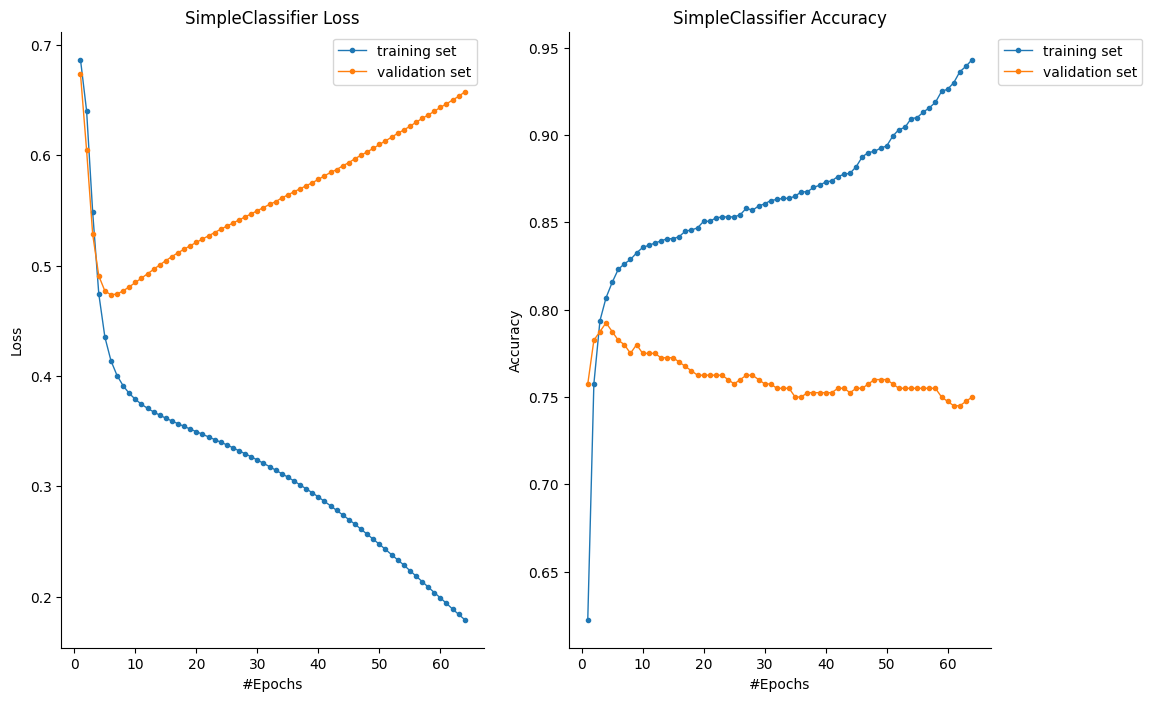

In [8]:
# init paramètre
nb_epochs = 64
optimizer = 'Adam'
lr = 0.001
input_dim = train_dataset.tensors[0].shape[1]
model = clf.SimpleClassifier(input_dim=input_dim).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("SimpleClassifier", train_loss, val_loss, train_acc, val_acc)

# LSTM

LSTMClassifier(
  (lstm): LSTM(250, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


326914 total parameters.
326914 training parameters.




  2%|▏         | 1/64 [00:00<00:10,  5.90it/s]

| Epoch: [1/64] | Train: Loss 0.6918 Accuracy : 0.5138 | Val: Loss 0.6828 Accuracy : 0.6550



  5%|▍         | 3/64 [00:00<00:06,  9.91it/s]

| Epoch: [2/64] | Train: Loss 0.6007 Accuracy : 0.7794 | Val: Loss 0.5307 Accuracy : 0.7175

| Epoch: [3/64] | Train: Loss 0.4008 Accuracy : 0.8150 | Val: Loss 0.5147 Accuracy : 0.7675

| Epoch: [4/64] | Train: Loss 0.3278 Accuracy : 0.8694 | Val: Loss 0.5630 Accuracy : 0.7550



...

| Epoch: [56/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9687 Accuracy : 0.7575

| Epoch: [57/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9728 Accuracy : 0.7575

| Epoch: [58/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9768 Accuracy : 0.7575



 95%|█████████▌| 61/64 [00:05<00:00, 12.17it/s]

| Epoch: [59/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9808 Accuracy : 0.7575

| Epoch: [60/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9848 Accuracy : 0.7575

| Epoch: [61/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9889 Accuracy : 0.7575



100%|██████████| 64/64 [00:05<00:00, 11.91it/s]

| Epoch: [62/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9929 Accuracy : 0.7600

| Epoch: [63/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9970 Accuracy : 0.7600

| Epoch: [64/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 2.0010 Accuracy : 0.7600


Test accuracy: 0.751


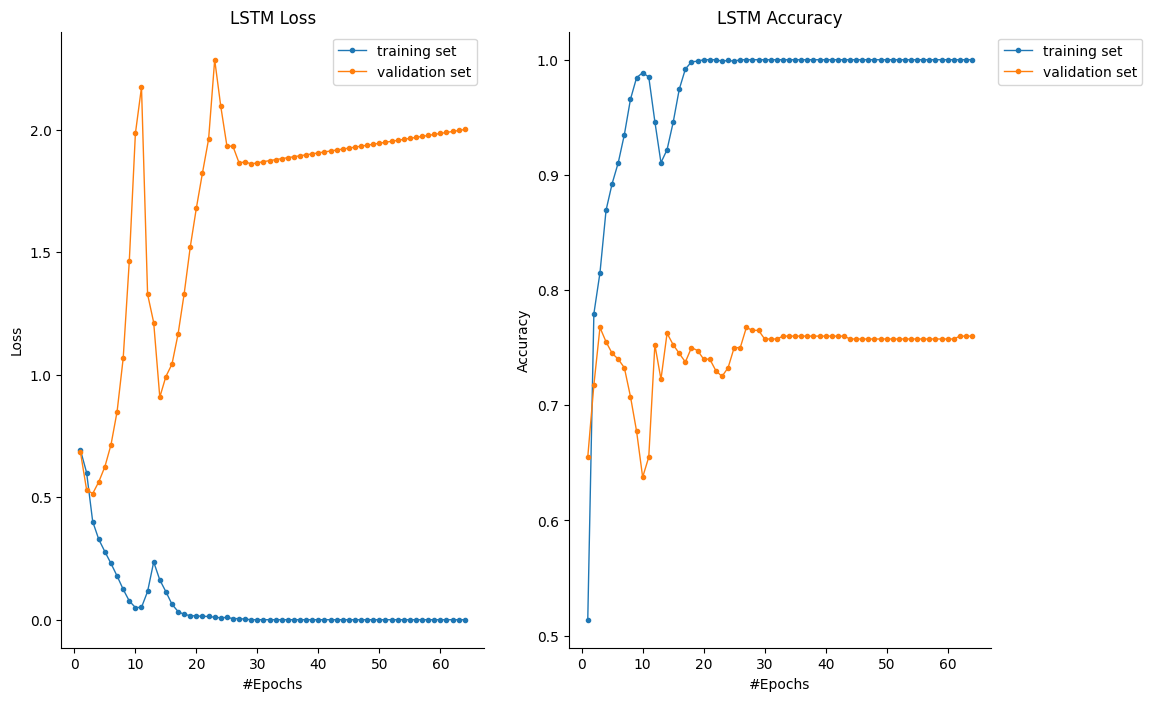

In [9]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMClassifier(input_dim=input_dim, hidden_dim=128, num_layers=2, output_dim=2, bidirectional=False).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("LSTM", train_loss, val_loss, train_acc, val_acc)

# Deeper LSTM

DeepLSTMClassifier(
  (lstm): LSTM(250, 128, num_layers=3, batch_first=True, dropout=0.4, bidirectional=True)
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1196226 total parameters.
1196226 training parameters.




  2%|▏         | 1/64 [00:00<00:15,  4.01it/s]

| Epoch: [1/64] | Train: Loss 0.6931 Accuracy : 0.5288 | Val: Loss 0.6897 Accuracy : 0.7400



  3%|▎         | 2/64 [00:00<00:14,  4.26it/s]

| Epoch: [2/64] | Train: Loss 0.5528 Accuracy : 0.7250 | Val: Loss 0.5632 Accuracy : 0.7700



...

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.6516 Accuracy : 0.7700



 98%|█████████▊| 63/64 [00:17<00:00,  3.64it/s]

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.6639 Accuracy : 0.7700



100%|██████████| 64/64 [00:18<00:00,  3.55it/s]

| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.6760 Accuracy : 0.7700


Test accuracy: 0.759


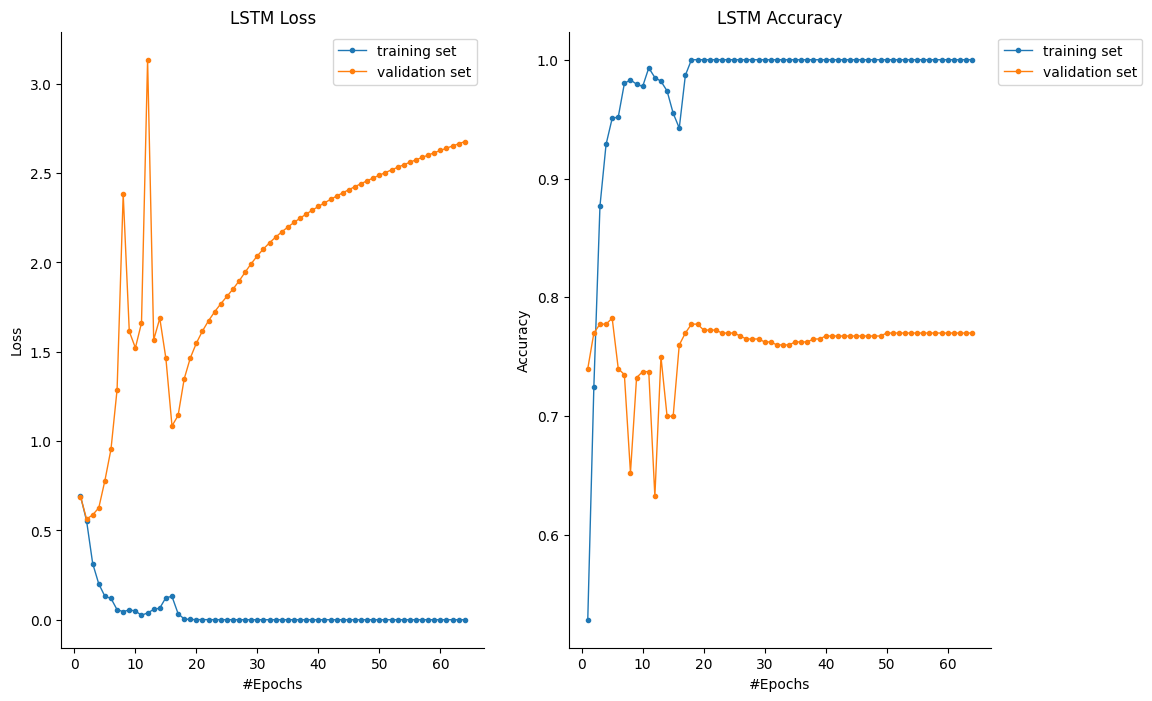

In [10]:
input_dim = X_train_tensor.shape[1]  
model = clf.DeepLSTMClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=3,
    fc_hidden_dim=64,
    output_dim=2,  # set this to the number of classes
    dropout=0.4,
    bidirectional=True
).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Deep LSTM", train_loss, val_loss, train_acc, val_acc)

# Attention LSTM

LSTMWithAttentionClassifier(
  (lstm): LSTM(250, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


801219 total parameters.
801219 training parameters.




  2%|▏         | 1/64 [00:00<00:14,  4.22it/s]

| Epoch: [1/64] | Train: Loss 0.6921 Accuracy : 0.5269 | Val: Loss 0.6814 Accuracy : 0.6675



  3%|▎         | 2/64 [00:00<00:13,  4.58it/s]

| Epoch: [2/64] | Train: Loss 0.5485 Accuracy : 0.7600 | Val: Loss 0.5641 Accuracy : 0.7600



...

| Epoch: [60/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.4009 Accuracy : 0.7625

| Epoch: [61/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.4127 Accuracy : 0.7625



 98%|█████████▊| 63/64 [00:12<00:00,  5.21it/s]

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.4243 Accuracy : 0.7625

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.4357 Accuracy : 0.7625



100%|██████████| 64/64 [00:13<00:00,  4.90it/s]


| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.4470 Accuracy : 0.7625


Test accuracy: 0.746


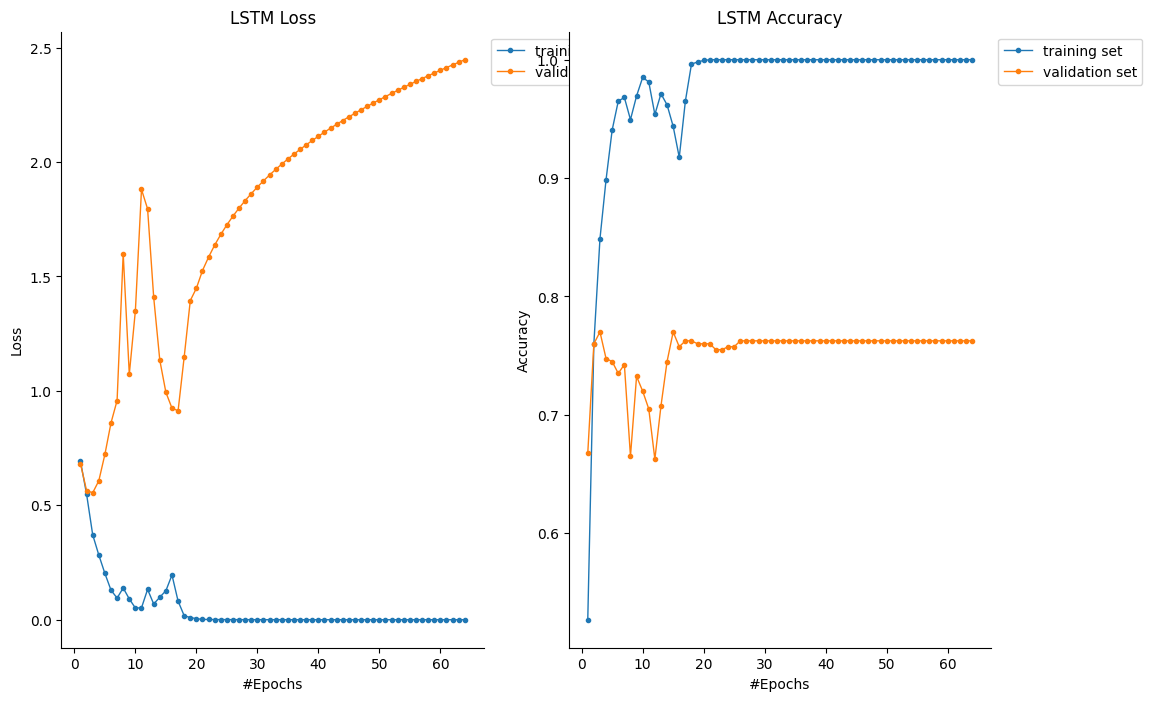

In [11]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMWithAttentionClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=2,
    output_dim=2,
    dropout=0.3,
    fc_hidden_dim=64,
    bidirectional=True
).to(device)


print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("LSTM with attention", train_loss, val_loss, train_acc, val_acc)

In [34]:
import numpy as np
import torch
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

def get_accuracy(y_true, y_pred):
    return int(np.sum(np.equal(y_true,y_pred))) / y_true.shape[0]

# Train function
def train_model(model, epochs, train_loader, val_loader, optimizer_name = 'Adam', learning_rate = 0.001, device=None):
  torch.manual_seed(42)
  # Init
  output_fn = torch.nn.Softmax(dim=1) # we instantiate the softmax activation function for the output probabilities
  criterion = nn.CrossEntropyLoss() # we instantiate the loss function
  optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=learning_rate) # we instantiate Adam optimizer that takes as inputs the model parameters and learning rate

  loss_valid,acc_valid =[],[]
  loss_train,acc_train =[],[]

  for epoch in tqdm(range(epochs)):
    torch.manual_seed(42)
    # Training loop
    model.train() # always specify that the model is in training mode
    running_loss = 0.0 # init loss
    running_acc = 0.

    # Loop over batches returned by the data loader
    for idx, batch in enumerate(train_loader):

      # get the inputs; batch is a tuple of (inputs, labels)
      inputs, labels = batch
      inputs = inputs.to(device) # put the data on the same device as the model
      labels = labels.to(device)

      print(f"[DEBUG] inputs type: {type(inputs)}")
      print(f"[DEBUG] inputs content: {inputs}")

      # put to zero the parameters gradients at each iteration to avoid accumulations
      optimizer.zero_grad()
      
      if isinstance(inputs, dict):  # for HuggingFace-style inputs
        out = model(**inputs)
      elif isinstance(inputs, tuple):  # for MoE or BERT with tuple input
        out = model(*inputs)
      else:  # for LSTM models
        out = model(inputs)

      #out = model(x=inputs) # get predictions
      loss = criterion(out, labels) # compute loss
      loss.backward() # compute gradients
      optimizer.step() # update model parameters according to these gradients and our optimizer strategy

      # Iteration train metrics
      running_loss += loss.view(1).item() # extract loss value 
      t_out = output_fn(out.detach()).cpu().numpy() # compute softmax (previously instantiated) and detach predictions from the model graph
      t_out=t_out.argmax(axis=1)  # the class with the highest energy is what we choose as prediction
      ground_truth = labels.cpu().numpy() # detach the labels from GPU device
      running_acc += get_accuracy(ground_truth, t_out)

    ### Epochs train metrics ###
    acc_train.append(running_acc/len(train_loader))
    loss_train.append(running_loss/len(train_loader))

    # compute loss and accuracy after an epoch on the train and valid set
    model.eval() # put the model in evaluation mode (this prevents the use of dropout layers for instance)

    ### VALIDATION DATA ###
    with torch.no_grad(): # since we're not training, we don't need to calculate the gradients for our outputs
      idx = 0
      for batch in val_loader:
        inputs,labels=batch
        inputs=inputs.to(device)
        labels=labels.to(device)
        if idx==0:
          #t_out = model(x=inputs)
          t_out = model(*inputs)
          t_loss = criterion(t_out, labels).view(1).item()
          t_out = output_fn(t_out).detach().cpu().numpy() # compute softmax (previously instantiated) and detach predictions from the model graph
          t_out=t_out.argmax(axis=1)  # the class with the highest energy is what we choose as prediction
          ground_truth = labels.cpu().numpy() # detach the labels from GPU device
        else:
          #out = model(x=inputs)
          out = model(*inputs)
          t_loss = np.hstack((t_loss,criterion(out, labels).item()))
          t_out = np.hstack((t_out,output_fn(out).argmax(axis=1).detach().cpu().numpy()))
          ground_truth = np.hstack((ground_truth,labels.detach().cpu().numpy()))
        idx+=1

      acc_valid.append(get_accuracy(ground_truth,t_out))
      loss_valid.append(np.mean(t_loss))

    print('| Epoch: [{}/{}] | Train: Loss {:.4f} Accuracy : {:.4f} '\
        '| Val: Loss {:.4f} Accuracy : {:.4f}\n'.format(epoch+1,epochs,loss_train[epoch],acc_train[epoch],loss_valid[epoch],acc_valid[epoch]))

  return loss_train, loss_valid, acc_train, acc_valid

def test_model(model, device, test_loader):
  output_fn = torch.nn.Softmax(dim=1)
  model.eval()
  torch.manual_seed(42)
  with torch.no_grad():
    idx = 0
    for batch in test_loader:
      inputs,labels=batch
      inputs=inputs.to(device)
      labels=labels.to(device)
      if idx==0:
        #t_out = model(x=inputs)
        t_out = model(*inputs)
        t_out = output_fn(t_out).detach().cpu().numpy()
        t_out=t_out.argmax(axis=1)
        ground_truth = labels.detach().cpu().numpy()
      else:
        #out = model(x=inputs)
        out = model(*inputs)
        t_out = np.hstack((t_out,output_fn(out).argmax(axis=1).detach().cpu().numpy()))
        ground_truth = np.hstack((ground_truth,labels.detach().cpu().numpy()))
      idx+=1

  return get_accuracy(ground_truth,t_out)

def plot_accuracy_loss(model_name, loss_train, loss_valid, acc_train, acc_valid) :
  """plot the accuracy and loss functions (for each epoch)
    early_stop_point = True: visualize the early stopping
  """

  fig = plt.figure(figsize = (12, 8))

  # --- Metrics plot
  def plot_metric(model_name, metric_train, metric_valid, metric_name) :
    """plot metrics of both datasets"""
    plt.plot(range(1, len(metric_train) + 1), metric_train, label='training set', marker='.', linestyle='solid',linewidth=1, markersize=6)
    plt.plot(range(1, len(metric_valid) + 1), metric_valid, label='validation set', marker='.', linestyle='solid',linewidth=1, markersize=6)
    # find position of lowest validation loss
    plt.title(f"{model_name} {metric_name}")
    plt.xlabel('#Epochs')
    plt.ylabel(f'{metric_name}')
    plt.legend(bbox_to_anchor=( 1., 1.))

  # Plot loss functions
  ax = fig.add_subplot(121)
  for side in ['right', 'top']:
    ax.spines[side].set_visible(False)
  plot_metric(model_name, loss_train, loss_valid, "Loss")

  # Plot accuracy function
  ax = fig.add_subplot(122)
  for side in ['right', 'top']:
    ax.spines[side].set_visible(False)
  plot_metric(model_name, acc_train, acc_valid, "Accuracy")


from transformers import DistilBertModel
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Expert, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

class GatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts):
        super(GatingNetwork, self).__init__()
        self.gate = nn.Sequential(
            nn.Linear(input_dim, num_experts),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.gate(x)

class MoEClassifier(nn.Module):
    def __init__(self, num_experts=3, expert_hidden=128, output_dim=2):
        super(MoEClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.bert.requires_grad_(False)  # freeze BERT

        self.input_dim = self.bert.config.hidden_size
        self.experts = nn.ModuleList([
            Expert(self.input_dim, expert_hidden, output_dim)
            for _ in range(num_experts)
        ])
        self.gate = GatingNetwork(self.input_dim, num_experts)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]  # CLS token

        gate_weights = self.gate(bert_output)  # (batch_size, num_experts)

        expert_outputs = torch.stack([expert(bert_output) for expert in self.experts], dim=1)  # (batch_size, num_experts, output_dim)

        # Weighted sum of expert outputs
        weighted_output = torch.sum(gate_weights.unsqueeze(-1) * expert_outputs, dim=1)  # (batch_size, output_dim)

        return weighted_output

In [35]:
model = MoEClassifier(num_experts=3, expert_hidden=128, output_dim=2)
model.to(device)


print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("MoE", train_loss, val_loss, train_acc, val_acc)

MoEClassifier(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(i

  0%|          | 0/64 [00:00<?, ?it/s]

[DEBUG] inputs type: <class 'torch.Tensor'>
[DEBUG] inputs content: tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0953, 0.0000, 0.0737,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.1315, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])


TypeError: MoEClassifier.forward() missing 1 required positional argument: 'attention_mask'